# Common discrete distributions

This notebook collects the discrete distributions that come up most often in this
course (Appendix A of the notes). For each one we list its parameters, the
probability mass function $f_X(x)=\mathbb{P}(X=x)$, the mean $\mathbb{E}[X]$, the
variance $\mathbb{V}[X]$, and the *moment generating function*
$M_X(t)=\mathbb{E}\bigl[e^{tX}\bigr]$, together with the values of $t$ for which it
is finite. The mass function is zero outside the values of $x$ listed.

**Disclaimer:** the definitions of the distributions are based on a writeup by
Prof. Dr. Subramanian Ramakrishnan at the University of Miami.

Each mass function is typed in from its formula in the notes, and each plot uses the
same parameters as the plot in the notes. Run the cells from top to bottom. Then
change the numbers in a cell and run it again to see how the distribution changes
shape.

Below each plot, the code checks the formulas: it adds up $f(x)$, $x\,f(x)$, and
$(x-\mu)^2 f(x)$ over the values of $x$, and compares the results with 1 and with the
mean and variance in the notes.

In [1]:
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

BLUE = "#3172AE"                  # the colour of the plots in the notes


# a stem plot of the values f at the points xs
def stem(xs, f, title):
    fig, ax = plt.subplots(figsize=(6, 3.2), layout="constrained")
    ax.vlines(xs, 0, f, color=BLUE, linewidth=2)
    ax.plot(xs, f, "o", color=BLUE)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))   # X takes whole numbers
    return ax


# compare the total probability, mean, and variance computed from the values f at
# the points xs with the ones in the notes; xs must reach far enough that the
# probability left out is negligible
def check(xs, f, mean, variance):
    total = sum(f)
    mu = sum(x * fx for x, fx in zip(xs, f))
    var = sum((x - mu)**2 * fx for x, fx in zip(xs, f))
    print(f"{'':12}{'from f(x)':>11}{'notes':>11}")
    print(f"{'total':12}{total:11.4f}{1:11.4f}")
    print(f"{'mean':12}{round(mu, 4) + 0:11.4f}{mean:11.4f}")   # + 0 turns -0.0 into 0.0
    print(f"{'variance':12}{var:11.4f}{variance:11.4f}")

## Hypergeometric

A population of $n$ objects contains $t$ marked ones; draw $m$ of them without
replacement, and let $X$ be the number of marked objects drawn.

$$
f_X(x)=\frac{\binom{t}{x}\binom{n-t}{m-x}}{\binom{n}{m}},\qquad x=0,1,\dots,m.
$$

* $\mathbb{E}[X]=m\,\dfrac{t}{n}$
* $\mathbb{V}[X]=m\,\dfrac{t}{n}\Bigl(1-\dfrac{t}{n}\Bigr)\Bigl(1-\dfrac{m-1}{n-1}\Bigr)$

> We use the convention $\binom{a}{b}=0$ for $b>a$, so values of $x$ with $x>t$ or
> $m-x>n-t$ have probability zero.

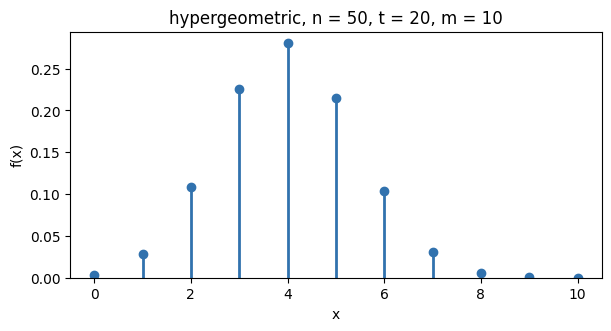

              from f(x)      notes
total            1.0000     1.0000
mean             4.0000     4.0000
variance         1.9592     1.9592


In [2]:
def hypergeometric(x, n, t, m):
    # math.comb(a, b) is 0 for b > a, the convention in the notes
    return math.comb(t, x) * math.comb(n - t, m - x) / math.comb(n, m)


n, t, m = 50, 20, 10
xs = list(range(0, m + 1))
f = [hypergeometric(x, n, t, m) for x in xs]
stem(xs, f, f"hypergeometric, n = {n}, t = {t}, m = {m}")
plt.show()

check(xs, f, mean=m * t / n,
      variance=m * t / n * (1 - t / n) * (1 - (m - 1) / (n - 1)))

## Bernoulli

Parameter $p\in[0,1]$; $X=1$ (success) with probability $p$ and $X=0$ otherwise.

$$
f_X(x)=p^{x}(1-p)^{1-x},\qquad x=0,1.
$$

* $\mathbb{E}[X]=p$
* $\mathbb{V}[X]=p(1-p)$
* $M_X(t)=1-p+pe^{t}$ for all $t\in\mathbb{R}$

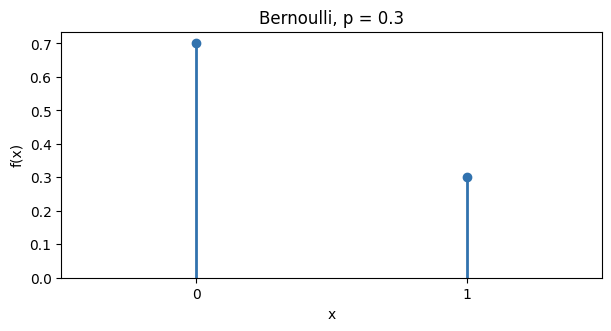

              from f(x)      notes
total            1.0000     1.0000
mean             0.3000     0.3000
variance         0.2100     0.2100


In [3]:
def bernoulli(x, p):
    return p**x * (1 - p)**(1 - x)


p = 0.3
xs = [0, 1]
f = [bernoulli(x, p) for x in xs]
ax = stem(xs, f, f"Bernoulli, p = {p}")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks(xs)
plt.show()

check(xs, f, mean=p, variance=p * (1 - p))

## Binomial

Parameters $n\in\{1,2,\dots\}$ and $p\in[0,1]$; $X$ is the number of successes in $n$
independent Bernoulli($p$) trials.

$$
f_X(x)=\binom{n}{x}p^{x}(1-p)^{n-x},\qquad x=0,1,\dots,n.
$$

* $\mathbb{E}[X]=np$
* $\mathbb{V}[X]=np(1-p)$
* $M_X(t)=\bigl(1-p+pe^{t}\bigr)^{n}$ for all $t\in\mathbb{R}$

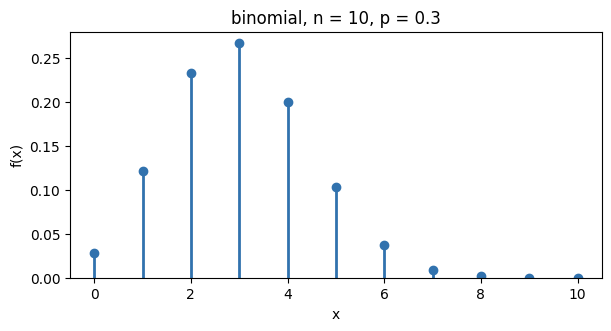

              from f(x)      notes
total            1.0000     1.0000
mean             3.0000     3.0000
variance         2.1000     2.1000


In [4]:
def binomial(x, n, p):
    return math.comb(n, x) * p**x * (1 - p)**(n - x)


n, p = 10, 0.3
xs = list(range(0, n + 1))
f = [binomial(x, n, p) for x in xs]
stem(xs, f, f"binomial, n = {n}, p = {p}")
plt.show()

check(xs, f, mean=n * p, variance=n * p * (1 - p))

## Geometric

Parameter $p\in(0,1)$; $X$ is the number of independent Bernoulli($p$) trials up to
and including the first success.

$$
f_X(x)=(1-p)^{x-1}p,\qquad x=1,2,\dots.
$$

* $\mathbb{E}[X]=\dfrac{1}{p}$
* $\mathbb{V}[X]=\dfrac{1-p}{p^{2}}$
* $M_X(t)=\dfrac{pe^{t}}{1-(1-p)e^{t}}$ for $t<-\ln(1-p)$

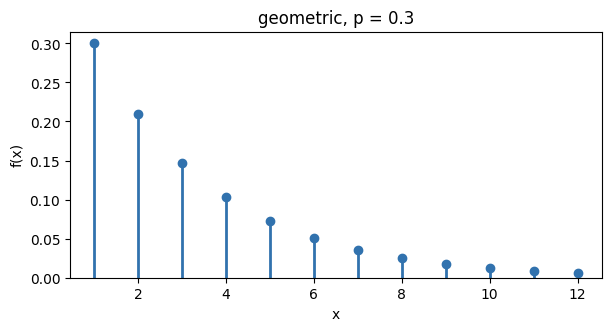

              from f(x)      notes
total            1.0000     1.0000
mean             3.3333     3.3333
variance         7.7778     7.7778


In [5]:
def geometric(x, p):              # x = trials up to and including the first success
    return (1 - p)**(x - 1) * p


p = 0.3
xs = list(range(1, 13))           # the values go on forever; plot the first 12
stem(xs, [geometric(x, p) for x in xs], f"geometric, p = {p}")
plt.show()

xs = list(range(1, 201))          # the check needs the far values too
check(xs, [geometric(x, p) for x in xs], mean=1 / p, variance=(1 - p) / p**2)

## Negative binomial

Parameters $r\in\{1,2,\dots\}$ and $p\in(0,1)$; $X$ is the number of independent
Bernoulli($p$) trials up to and including the $r$-th success.

$$
f_X(x)=\binom{x-1}{r-1}(1-p)^{x-r}p^{r},\qquad x=r,r+1,\dots.
$$

* $\mathbb{E}[X]=\dfrac{r}{p}$
* $\mathbb{V}[X]=\dfrac{r(1-p)}{p^{2}}$
* $M_X(t)=\Bigl(\dfrac{pe^{t}}{1-(1-p)e^{t}}\Bigr)^{r}$ for $t<-\ln(1-p)$

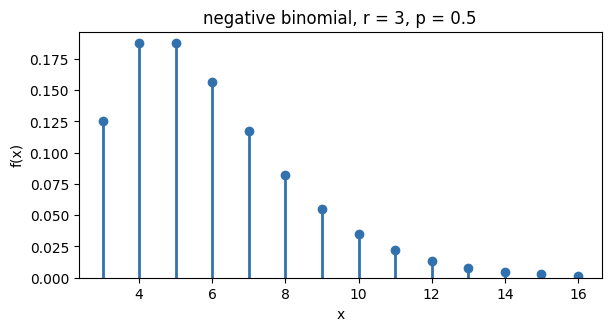

              from f(x)      notes
total            1.0000     1.0000
mean             6.0000     6.0000
variance         6.0000     6.0000


In [6]:
def negative_binomial(x, r, p):   # x = trials up to and including the r-th success
    return math.comb(x - 1, r - 1) * (1 - p)**(x - r) * p**r


r, p = 3, 0.5
xs = list(range(r, 17))           # starts at x = r
stem(xs, [negative_binomial(x, r, p) for x in xs],
     f"negative binomial, r = {r}, p = {p}")
plt.show()

xs = list(range(r, 201))          # the check needs the far values too
check(xs, [negative_binomial(x, r, p) for x in xs],
      mean=r / p, variance=r * (1 - p) / p**2)

## Poisson

Parameter $\lambda>0$; $X$ counts events that occur independently at average rate
$\lambda$.

$$
f_X(x)=\frac{e^{-\lambda}\lambda^{x}}{x!},\qquad x=0,1,2,\dots.
$$

* $\mathbb{E}[X]=\lambda$
* $\mathbb{V}[X]=\lambda$
* $M_X(t)=e^{\lambda(e^{t}-1)}$ for all $t\in\mathbb{R}$

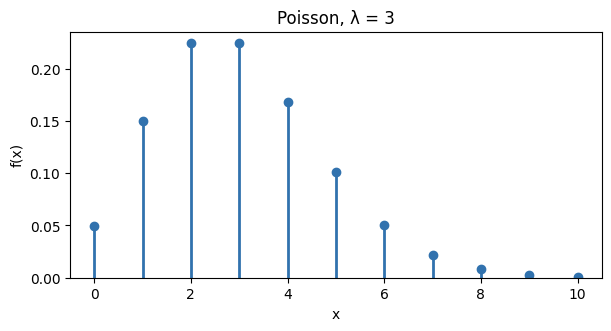

              from f(x)      notes
total            1.0000     1.0000
mean             3.0000     3.0000
variance         3.0000     3.0000


In [7]:
def poisson(x, lam):              # lambda is a reserved word in Python
    return math.exp(-lam) * lam**x / math.factorial(x)


lam = 3
xs = list(range(0, 11))           # the values go on forever; plot the first 11
stem(xs, [poisson(x, lam) for x in xs], f"Poisson, λ = {lam}")
plt.show()

xs = list(range(0, 101))          # the check needs the far values too
check(xs, [poisson(x, lam) for x in xs], mean=lam, variance=lam)

## Built-in functions

In your own code you will usually call the built-in mass functions in `scipy.stats`
instead of typing in the formulas. Several of them take different parameters than the
notes; for example, `stats.nbinom` counts the failures before the $r$-th success,
which is $X-r$. The table in [`README.md`](README.md) gives the call that matches
each $f_X(x)$ above.

---
This notebook is part of STAN (Statistics: Theory, Applications & Numerics), the code
repository for MATH 166 at Tufts University: <https://github.com/andreasmang/stan>